## Prediction of Medical Costs using Linear Regression

The healthcare industry is one of the most important industries worldwide (Cao, 2023). However the affordability of quality healthcare services differs from place to place. Healthcare costs are influenced by several factors such as demographic and lifestyle factors (Cao, 2023). Medical cost prediction is therefore an important task that can aid policymakers and hospitals in their estimation of patient expenses, so that resources can be allocated effectively. There are a number of methods and tools that can be used to predict medical costs, linear regression being one of them (Dai, 2024).
Linear regression is a well-known and widely used statistical method that estimates the relationship between the dependent variable and independent variables (Roustaei, 2024). This technique is divided into two types based on the number of variables in the model, simple linear regression and multiple linear regression (Taloba et al., 2022). Multiple linear regression describes associations of several independent variables with one continuous outcome, the dependent variable. This method is an extension of the simple linear regression model that uses one independent variable (Trunfio et al., 2022). In this study we will use multiple linear regression to predict medical costs based on insurance data. This is because our data has more than one independent variable, making the chosen type of linear regression more suitable.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Loading the dataset
df = pd.read_csv("insurance.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


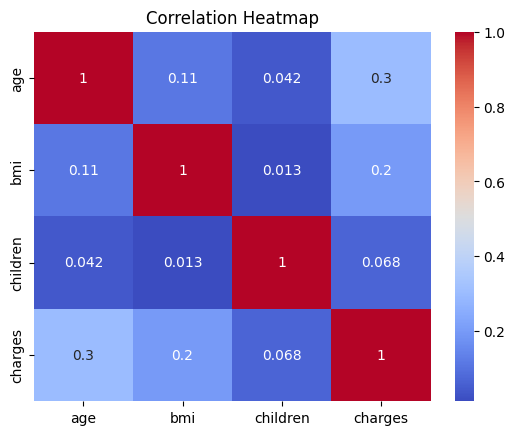

In [12]:
#Variable description

print(df.info())
print(df.head())

# Correlation among variables

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


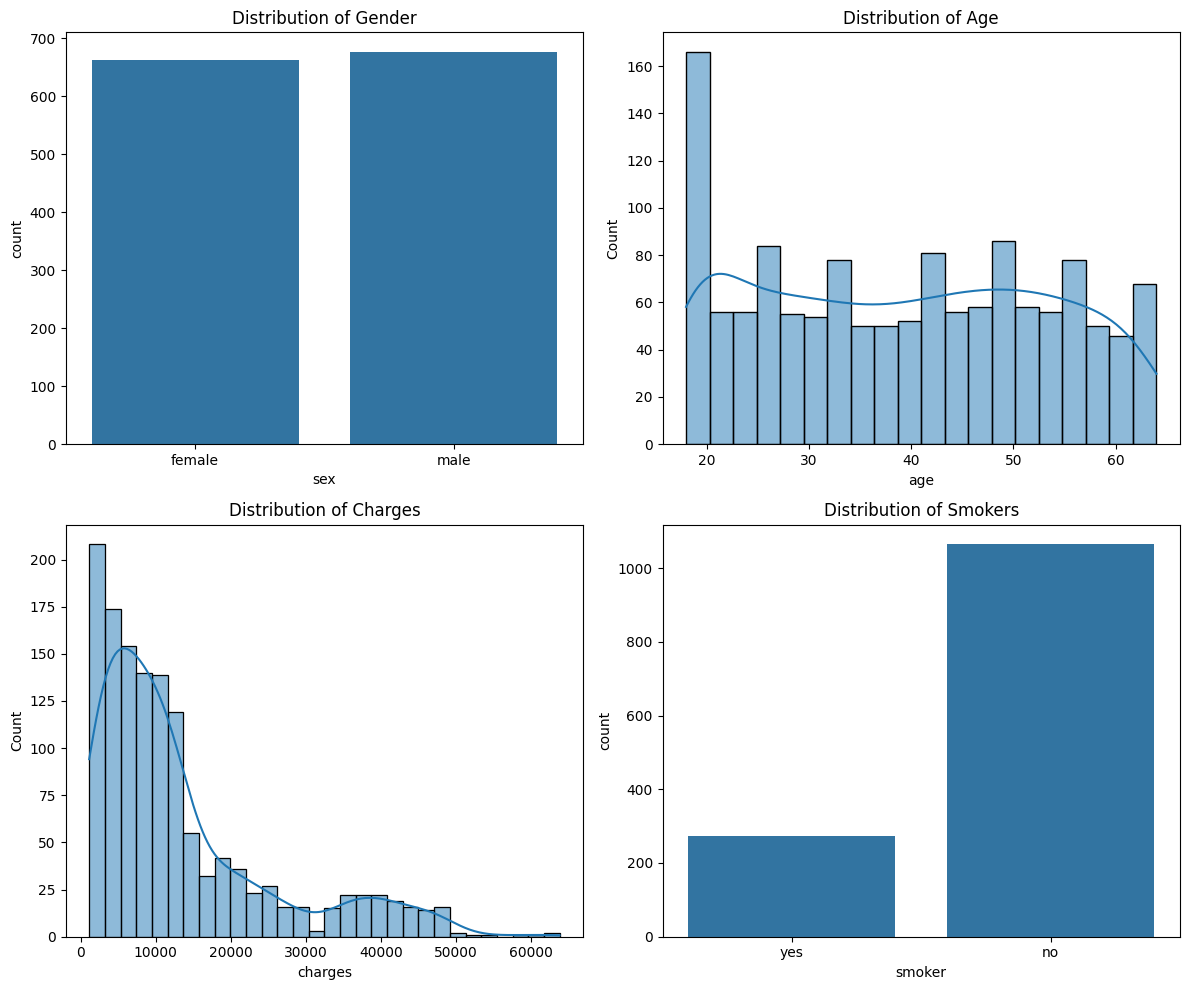

In [13]:
# Distributions

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(x="sex", data=df, ax=axes[0,0])
axes[0,0].set_title("Distribution of Gender")

sns.histplot(df["age"], kde=True, bins=20, ax=axes[0,1])
axes[0,1].set_title("Distribution of Age")

sns.histplot(df["charges"], kde=True, bins=30, ax=axes[1,0])
axes[1,0].set_title("Distribution of Charges")

sns.countplot(x="smoker", data=df, ax=axes[1,1])
axes[1,1].set_title("Distribution of Smokers")

plt.tight_layout()
plt.show()



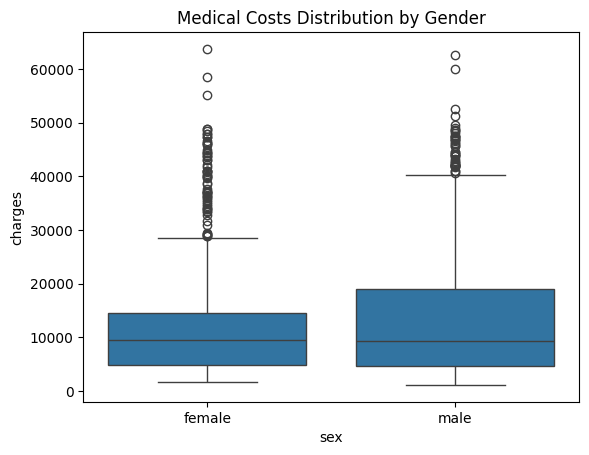

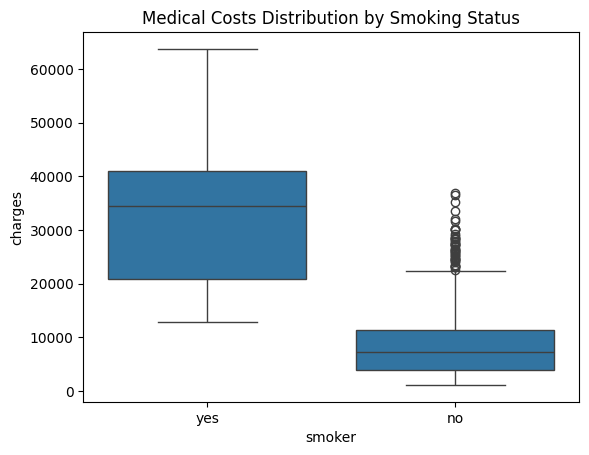

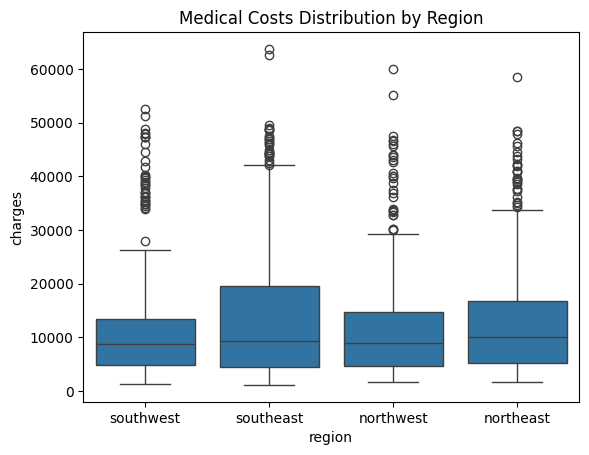

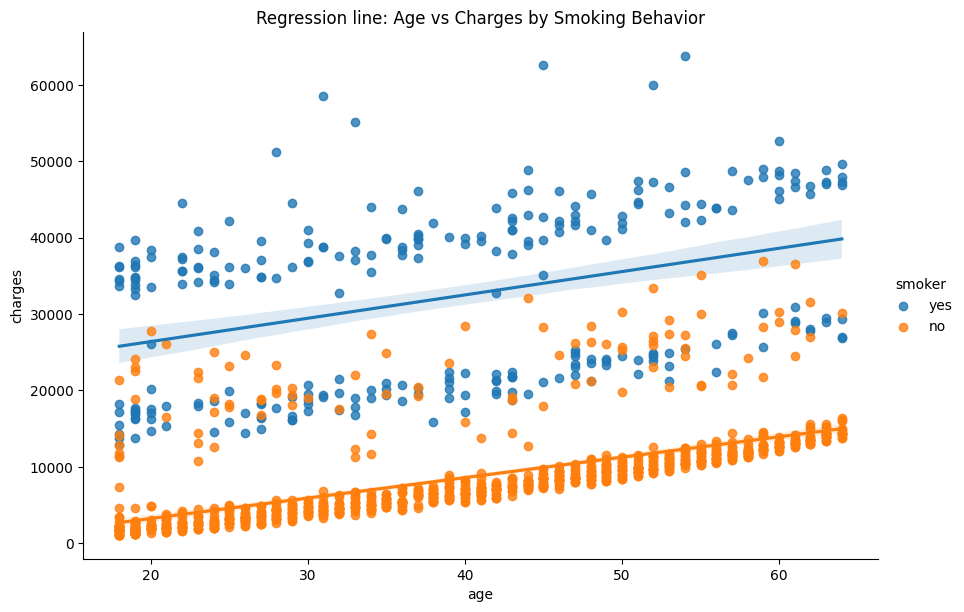

In [14]:
#  Distribution of costs by gender

sns.boxplot(x="sex", y="charges", data=df)
plt.title("Medical Costs Distribution by Gender")
plt.show()

# Distribution of costs by smoking status
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Medical Costs Distribution by Smoking Status")
plt.show()

# Distribution of costs by region

sns.boxplot(x="region", y="charges", data=df)
plt.title("Medical Costs Distribution by Region")
plt.show()

# Regression line (age vs costs)

sns.lmplot(
    x="age", y="charges", hue="smoker",
    data=df, height=6, aspect=1.5
)

plt.title("Regression line: Age vs Charges by Smoking Behavior")
plt.show()


In [15]:
# Train/Test Split & Model

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.4f}")



Model Performance:
MAE: 4181.19
MSE: 33596915.85
RMSE: 5796.28
R^2: 0.7836


The analysis of the insurance dataset brought to light a number of important observations about factors that affect medical costs. The correlation heatmap revealed that age and BMI show a positive association with medical charges, however this association is somewhat weak in isolation. This suggests that categorical factors, particularly smoking status, is likely to be a stronger predictor of medical costs than numeric variables alone.
Our regression line plot of age vs. medical charges showed a positive trend depicted by the upward slope, suggesting that as age increases, so do medical costs. However, it is worth noting that there’s a wide spread of charges at nearly every age level. It is clear on this plot that Medical costs for smokers are higher than for non-smokers, as shown by the 2 trendlines. This further emphasises that age alone does not fully explain the variation in medical charges.
The boxplot in figure 3 showed that gender and region are not strong determinants of medical costs on their own. For gender the distribution was similar between males and females, while for region the median looked similar across, with southeast showing a slightly higher spread suggesting demographic differences. In contrast, the smoking status boxplot (right) clearly showed that whether one is a smoker or not has a strong influence on medical costs. The median cost of smokers is significantly higher and the spread of charges is wider. This confirms the strong association between smoking and high healthcare expenses as smoking is linked to chronic conditions and long-term healthcare needs (Huang et al., 2021).
The model performed relatively well, capturing most of the variation in charges as shown by an R2 of 0.78. However the error values were still relatively large, an MAE of 4181 tells us that our model’s predictions were off by ~ $4200 compared to actual charges.
